# Test Model Adapters

This notebook verifies the standardized model adapter layer:

1. **Path Resolution** - Verifies `ModelPathResolver` locates configs and checkpoints.
2. **Model Loading** - Tests `MMPoseAdapter` with all three backbones.
3. **Inference & Standardized Formats** - Validates `StandardizedHeatmap` and coordinate outputs.
4. **Factory Integration** - Tests `create_model_adapter()` interface.

## Available Architectures:
- **ResNet-50**: Classical baseline
- **HRNet-W32**: High-Resolution Network
- **ViTPose-Small**: Vision Transformer architecture

## 1. Setup & Environment Configuration

In [1]:
import os
import sys
from pathlib import Path

# Resolve project root dynamically
project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
    Path.cwd().parent
)
PROJECT_ROOT = project_root
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
mmpose_root = project_root / "models" / "mmpose"
if mmpose_root.exists() and str(mmpose_root) not in sys.path:
    sys.path.insert(0, str(mmpose_root))

print(f"Project root: {project_root}")

import os
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

# Configurar logging
logging.basicConfig(level=logging.INFO)
warnings.filterwarnings("ignore")

# Obtain project paths

# Agregar src al path

print(f"📁 Project Root: {PROJECT_ROOT}")
print(f"✅ PyTorch Version: {torch.__version__}")
print(f"✅ CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

Project root: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta
📁 Project Root: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta
✅ PyTorch Version: 2.1.2+cu121
✅ CUDA Available: True
   GPU: NVIDIA GeForce RTX 2080 SUPER


## 2. Test: ModelPathResolver

In [2]:
from pose_uncertainty.models.adapters import ModelPathResolver

# Crear resolver
resolver = ModelPathResolver(PROJECT_ROOT)

print("=== ModelPathResolver ===\n")
print(f"📁 Project Root: {resolver.project_root}")
print(f"📁 MMPose Root: {resolver.mmpose_root}")
print(f"📁 Weights Dir: {resolver.weights_dir}")
print(f"📁 Configs Dir: {resolver.configs_dir}")

# Verify directories exist
print("\n=== Directory Verification ===")
print(f"✅ MMPose existe: {resolver.mmpose_root.exists()}")
print(f"✅ Weights existe: {resolver.weights_dir.exists()}")
print(f"✅ Configs existe: {resolver.configs_dir.exists()}")

=== ModelPathResolver ===

📁 Project Root: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta
📁 MMPose Root: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\mmpose
📁 Weights Dir: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\weights
📁 Configs Dir: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\mmpose\configs

=== Directory Verification ===
✅ MMPose existe: True
✅ Weights existe: True
✅ Configs existe: True


In [3]:
# Path resolution tests
test_configs = [
    "body_2d_keypoint/topdown_heatmap/coco/td-hm_res50_8xb64-210e_coco-256x192.py",
    "body_2d_keypoint/topdown_heatmap/coco/td-hm_hrnet-w32_8xb64-210e_coco-256x192.py",
    "body_2d_keypoint/topdown_heatmap/coco/td-hm_ViTPose-small_8xb64-210e_coco-256x192.py"
]

test_checkpoints = ["resnet50.pth", "hrnet_w32.pth", "vitpose_small_mmpose.pth"]

print("=== Config Resolution Test ===")
for config in test_configs:
    try:
        resolved = resolver.resolve_config(config)
        print(f"✅ {config.split('/')[-1]}: {resolved.name}")
    except FileNotFoundError as e:
        print(f"❌ {config.split('/')[-1]}: No encontrado")

print("\n=== Checkpoint Resolution Test ===")
for checkpoint in test_checkpoints:
    try:
        resolved = resolver.resolve_checkpoint(checkpoint)
        size_mb = resolved.stat().st_size / (1024 * 1024)
        print(f"✅ {checkpoint}: {size_mb:.2f} MB")
    except FileNotFoundError as e:
        print(f"❌ {checkpoint}: No encontrado")

=== Config Resolution Test ===
✅ td-hm_res50_8xb64-210e_coco-256x192.py: td-hm_res50_8xb64-210e_coco-256x192.py
✅ td-hm_hrnet-w32_8xb64-210e_coco-256x192.py: td-hm_hrnet-w32_8xb64-210e_coco-256x192.py
✅ td-hm_ViTPose-small_8xb64-210e_coco-256x192.py: td-hm_ViTPose-small_8xb64-210e_coco-256x192.py

=== Checkpoint Resolution Test ===
✅ resnet50.pth: 129.97 MB
✅ hrnet_w32.pth: 109.36 MB
✅ vitpose_small_mmpose.pth: 92.71 MB


## 3. Test: list_available_models()

In [4]:
from pose_uncertainty.models import list_available_models, MMPoseAdapter

print("=== Available Models ===")
models = list_available_models()
for model_name in models:
    info = MMPoseAdapter.MODEL_REGISTRY[model_name]
    print(f"\n📦 {model_name}:")
    print(f"   Config: {info['config'].split('/')[-1]}")
    print(f"   Checkpoint: {info['checkpoint']}")
    print(f"   Input Size: {info['input_size']}")

=== Available Models ===

📦 resnet50:
   Config: td-hm_res50_8xb64-210e_coco-256x192.py
   Checkpoint: resnet50.pth
   Input Size: (256, 192)

📦 hrnet_w32:
   Config: td-hm_hrnet-w32_8xb64-210e_coco-256x192.py
   Checkpoint: hrnet_w32.pth
   Input Size: (256, 192)

📦 vitpose_small:
   Config: td-hm_ViTPose-small_8xb64-210e_coco-256x192.py
   Checkpoint: vitpose_small_mmpose.pth
   Input Size: (256, 192)


## 4. Test: Model Instantiation via create_model_adapter()

In [5]:
from pose_uncertainty.models import create_model_adapter

# Determinar dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🎯 Usando dispositivo: {device}\n")

# Load all available models
loaded_models = {}

for model_name in list_available_models():
    print(f"{'='*60}")
    print(f"🔄 Loading {model_name}...")
    
    try:
        model = create_model_adapter(
            model_name=model_name,
            device=device,
            project_root=PROJECT_ROOT
        )
        loaded_models[model_name] = model
        
        print(f"✅ {model_name} loaded successfully:")
        print(f"   - Model Name: {model.model_name}")
        print(f"   - Input Size: {model.input_size}")
        print(f"   - Num Keypoints: {model.num_keypoints}")
        print(f"   - Device: {model.device}")
        print(f"   - Keypoint Names: {model.keypoint_names[:5]}...")
        
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*60}")
print(f"📊 Summary: {len(loaded_models)}/{len(list_available_models())} models loaded")

INFO:pose_uncertainty.models.adapters:Resolved config: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\mmpose\configs\body_2d_keypoint\topdown_heatmap\coco\td-hm_res50_8xb64-210e_coco-256x192.py
INFO:pose_uncertainty.models.adapters:Resolved checkpoint: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\weights\resnet50.pth


🎯 Usando dispositivo: cuda

🔄 Loading resnet50...
Loads checkpoint by local backend from path: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\weights\resnet50.pth


INFO:pose_uncertainty.models.adapters:Initialized res50 adapter:
  - Input size: (192, 256)
  - Num keypoints: 17
  - Device: cuda
INFO:pose_uncertainty.models.adapters:Resolved config: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\mmpose\configs\body_2d_keypoint\topdown_heatmap\coco\td-hm_hrnet-w32_8xb64-210e_coco-256x192.py
INFO:pose_uncertainty.models.adapters:Resolved checkpoint: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\weights\hrnet_w32.pth


✅ resnet50 loaded successfully:
   - Model Name: res50
   - Input Size: (192, 256)
   - Num Keypoints: 17
   - Device: cuda
   - Keypoint Names: ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear']...
🔄 Loading hrnet_w32...
Loads checkpoint by local backend from path: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\weights\hrnet_w32.pth


INFO:pose_uncertainty.models.adapters:Initialized hrnet-w32 adapter:
  - Input size: (192, 256)
  - Num keypoints: 17
  - Device: cuda
INFO:pose_uncertainty.models.adapters:Resolved config: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\mmpose\configs\body_2d_keypoint\topdown_heatmap\coco\td-hm_ViTPose-small_8xb64-210e_coco-256x192.py
INFO:pose_uncertainty.models.adapters:Resolved checkpoint: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\weights\vitpose_small_mmpose.pth


✅ hrnet_w32 loaded successfully:
   - Model Name: hrnet-w32
   - Input Size: (192, 256)
   - Num Keypoints: 17
   - Device: cuda
   - Keypoint Names: ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear']...
🔄 Loading vitpose_small...


INFO:pose_uncertainty.models.adapters:Initialized ViTPose-small adapter:
  - Input size: (192, 256)
  - Num keypoints: 17
  - Device: cuda


Loads checkpoint by local backend from path: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\models\weights\vitpose_small_mmpose.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: backbone.cls_token

✅ vitpose_small loaded successfully:
   - Model Name: ViTPose-small
   - Input Size: (192, 256)
   - Num Keypoints: 17
   - Device: cuda
   - Keypoint Names: ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear']...

📊 Summary: 3/3 models loaded


## 5. Test: MockPoseModel (CPU Testing / CI Validation)

=== Test MockPoseModel ===
✅ unimodal: shape=(17, 64, 48), range=[0.000, 1.000]
✅ bimodal: shape=(17, 64, 48), range=[0.000, 1.000]
✅ uniform: shape=(17, 64, 48), range=[0.000, 1.000]
✅ noisy: shape=(17, 64, 48), range=[0.000, 1.000]


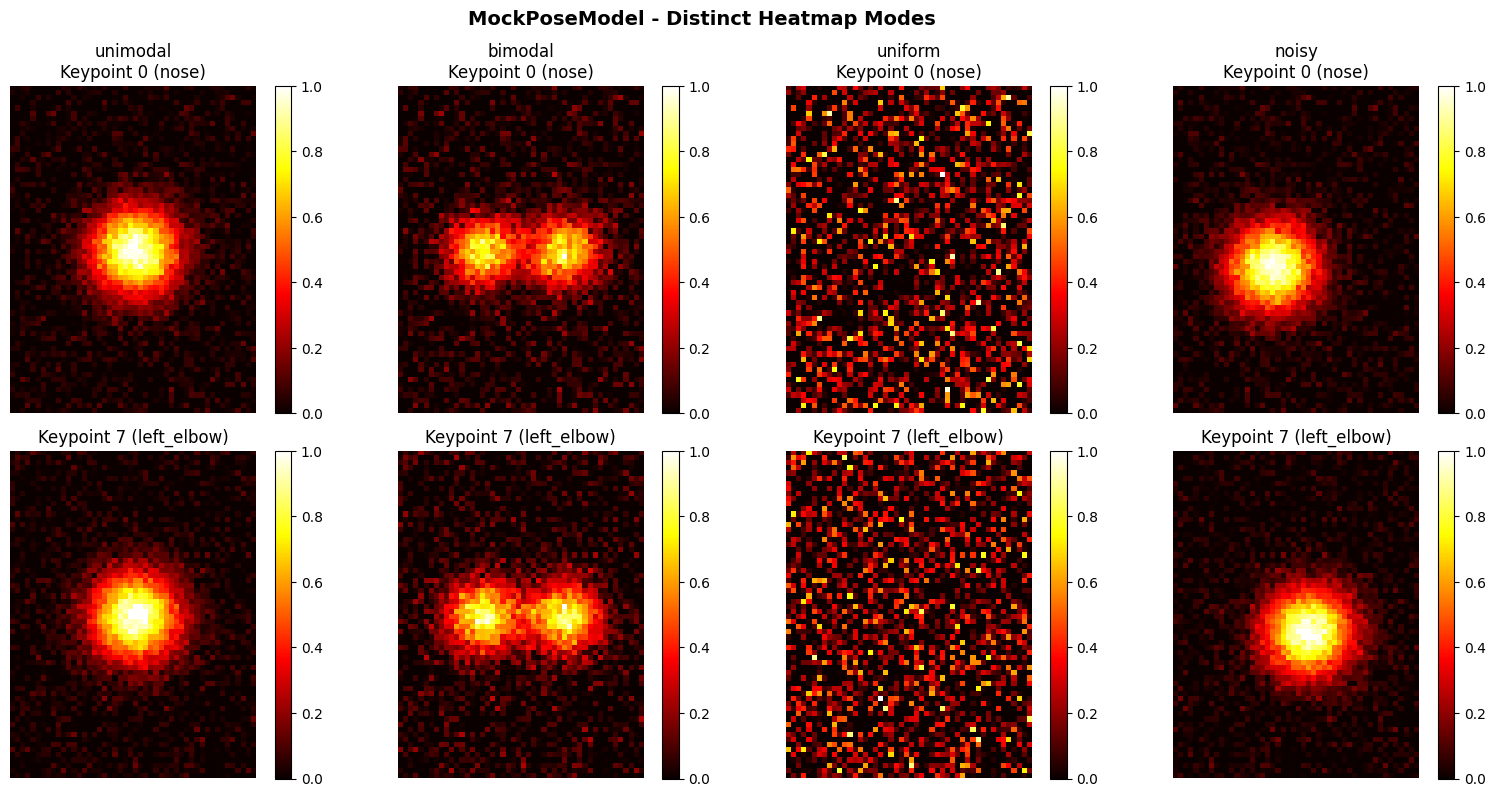

In [6]:
from pose_uncertainty.models import MockPoseModel

print("=== Test MockPoseModel ===")

# Test distinct modes
modes = ["unimodal", "bimodal", "uniform", "noisy"]

# Create dummy image
dummy_image = np.random.randint(0, 255, (256, 192, 3), dtype=np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, mode in enumerate(modes):
    mock = MockPoseModel(mode=mode, noise_level=0.05)
    result = mock.predict(dummy_image)
    
    # Display first keypoint
    ax1 = axes[0, idx]
    im = ax1.imshow(result.data[0], cmap='hot')
    ax1.set_title(f"{mode}\nKeypoint 0 (nose)")
    ax1.axis('off')
    plt.colorbar(im, ax=ax1, fraction=0.046)
    
    # Display elbow keypoint
    ax2 = axes[1, idx]
    im = ax2.imshow(result.data[7], cmap='hot')
    ax2.set_title(f"Keypoint 7 (left_elbow)")
    ax2.axis('off')
    plt.colorbar(im, ax=ax2, fraction=0.046)
    
    print(f"✅ {mode}: shape={result.data.shape}, range=[{result.data.min():.3f}, {result.data.max():.3f}]")

plt.suptitle("MockPoseModel - Distinct Heatmap Modes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Prepare Test Sample from COCO

🔄 Loading COCO dataset...
Loading annotations from c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\data\coco\annotations/person_keypoints_val2017.json...
loading annotations into memory...
Done (t=0.21s)
creating index...
index created!
Dataset loaded: 2693 images discovered.
✅ Dataset loaded: 2693 images

✅ Test image loaded:
   ID: 458755
   Shape: (480, 640, 3)
   BBox: (69.03, 37.75, 508.05, 435.78)


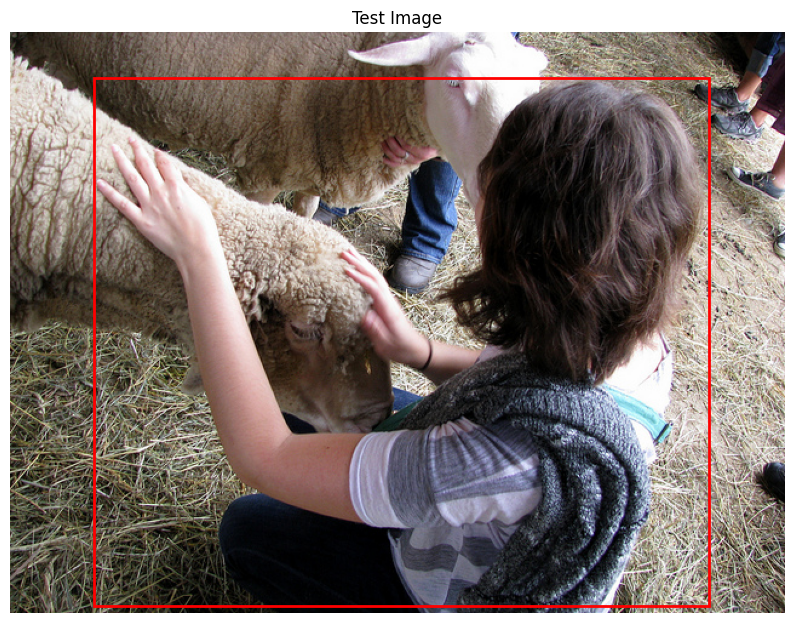

In [7]:
from pose_uncertainty.data_loader import COCOLoader
import cv2

# Configure COCO dataset paths
coco_data_root = PROJECT_ROOT / "data" / "coco"
coco_ann_file = "annotations/person_keypoints_val2017.json"
coco_image_dir = "val2017"

test_image = None
test_bbox = None
test_keypoints_gt = None

# Attempt loading from COCO
if coco_data_root.exists() and (coco_data_root / coco_ann_file).exists():
    try:
        print("🔄 Loading COCO dataset...")
        coco_loader = COCOLoader(
            data_root=str(coco_data_root),
            ann_file=coco_ann_file,
            image_dir=coco_image_dir
        )
        
        print(f"✅ Dataset loaded: {len(coco_loader)} images")
        
        # Get sample
        coco_iterator = iter(coco_loader)
        next(coco_iterator)  # Skip first (might be problematic)
        
        sample = next(coco_iterator)
        
        test_image = sample.image_array
        test_bbox = sample.bbox
        test_keypoints_gt = sample.ground_truth_keypoints
        
        print(f"\n✅ Test image loaded:")
        print(f"   ID: {sample.image_id}")
        print(f"   Shape: {test_image.shape}")
        print(f"   BBox: {test_bbox}")
        
    except Exception as e:
        print(f"❌ Error loading COCO: {e}")
else:
    print("⚠️ COCO dataset not found")

# Fallback: Synthetic image
if test_image is None:
    print("\n🔄 Creating synthetic image...")
    test_image = np.ones((480, 640, 3), dtype=np.uint8) * 200
    
    # Draw simple human figure
    cv2.circle(test_image, (320, 150), 40, (100, 100, 100), -1)  # Head
    cv2.line(test_image, (320, 190), (320, 350), (100, 100, 100), 20)  # Torso
    cv2.line(test_image, (320, 220), (250, 320), (100, 100, 100), 15)  # Left arm
    cv2.line(test_image, (320, 220), (390, 320), (100, 100, 100), 15)  # Right arm
    cv2.line(test_image, (320, 350), (270, 480), (100, 100, 100), 15)  # Left leg
    cv2.line(test_image, (320, 350), (370, 480), (100, 100, 100), 15)  # Right leg
    
    test_bbox = None
    print(f"✅ Synthetic image created: {test_image.shape}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(test_image)
if test_bbox is not None:
    x, y, w, h = test_bbox
    rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)
ax.set_title("Test Image")
ax.axis('off')
plt.show()


## 7. Test: Inference Execution with Loaded Adapters

In [8]:
if len(loaded_models) > 0:
    print("=" * 70)
    print("RUNNING INFERENCE")
    print("=" * 70)
    
    inference_results = {}
    
    for model_name, model in loaded_models.items():
        print(f"\n🔄 Inference with {model_name}...")
        
        try:
            # Run prediction (StandardizedHeatmap)
            heatmap_result = model.predict(test_image, bbox=test_bbox)
            
            # Also obtain direct keypoints
            keypoints, scores = model.predict_keypoints(test_image, bbox=test_bbox)
            
            inference_results[model_name] = {
                'heatmap': heatmap_result,
                'keypoints': keypoints,
                'scores': scores
            }
            
            print(f"✅ Inference completed:")
            print(f"   - Heatmap shape: {heatmap_result.data.shape}")
            print(f"   - Heatmap range: [{heatmap_result.data.min():.3f}, {heatmap_result.data.max():.3f}]")
            print(f"   - Original size: {heatmap_result.original_size}")
            print(f"   - Scale factor: {heatmap_result.scale_factor}")
            
            # Keypoint statistics
            num_detected = np.sum(scores > 0.3)
            avg_score = np.mean(scores[scores > 0.3]) if num_detected > 0 else 0
            print(f"   - Keypoints detected (conf > 0.3): {num_detected}/17")
            print(f"   - Average confidence: {avg_score:.3f}")
            
        except Exception as e:
            print(f"❌ Inference error: {e}")
            import traceback
            traceback.print_exc()
    
    print(f"\n{'='*70}")
    print(f"📊 Summary: {len(inference_results)}/{len(loaded_models)} successful inferences")
else:
    print("⚠️ No models loaded for inference")


RUNNING INFERENCE

🔄 Inference with resnet50...


✅ Inference completed:
   - Heatmap shape: (17, 64, 48)
   - Heatmap range: [0.000, 1.000]
   - Original size: (480, 640)
   - Scale factor: 1.0
   - Keypoints detected (conf > 0.3): 13/17
   - Average confidence: 0.613

🔄 Inference with hrnet_w32...
✅ Inference completed:
   - Heatmap shape: (17, 64, 48)
   - Heatmap range: [0.000, 1.000]
   - Original size: (480, 640)
   - Scale factor: 1.0
   - Keypoints detected (conf > 0.3): 14/17
   - Average confidence: 0.631

🔄 Inference with vitpose_small...
✅ Inference completed:
   - Heatmap shape: (17, 64, 48)
   - Heatmap range: [0.000, 1.000]
   - Original size: (480, 640)
   - Scale factor: 1.0
   - Keypoints detected (conf > 0.3): 12/17
   - Average confidence: 0.700

📊 Summary: 3/3 successful inferences



--- Model: resnet50 | heatmaps shape: (17, 64, 48) | scale_factor: 1.0 ---
KP 00: score=0.645, sum=46.1, nonzero=3071, argmax=(24, 29), mapped~(29.0,24.0), kp_pred=[392.2, 142.0]
KP 01: score=0.721, sum=45.2, nonzero=3071, argmax=(22, 31), mapped~(31.0,22.0), kp_pred=[409.1, 132.6]
KP 02: score=0.492, sum=50.5, nonzero=3071, argmax=(22, 30), mapped~(30.0,22.0), kp_pred=[405.8, 125.0]
KP 03: score=0.709, sum=42.9, nonzero=3071, argmax=(26, 32), mapped~(32.0,26.0), kp_pred=[427.1, 172.1]
KP 04: score=0.672, sum=44.2, nonzero=3071, argmax=(27, 41), mapped~(41.0,27.0), kp_pred=[542.9, 186.7]
KP 05: score=0.659, sum=49.8, nonzero=3071, argmax=(40, 30), mapped~(30.0,40.0), kp_pred=[400.9, 359.3]
KP 06: score=0.540, sum=66.0, nonzero=3071, argmax=(36, 38), mapped~(38.0,36.0), kp_pred=[510.9, 312.4]
KP 07: score=0.917, sum=38.7, nonzero=3071, argmax=(39, 16), mapped~(16.0,39.0), kp_pred=[212.1, 351.9]
KP 08: score=0.681, sum=49.5, nonzero=3071, argmax=(33, 26), mapped~(26.0,33.0), kp_pred=[35

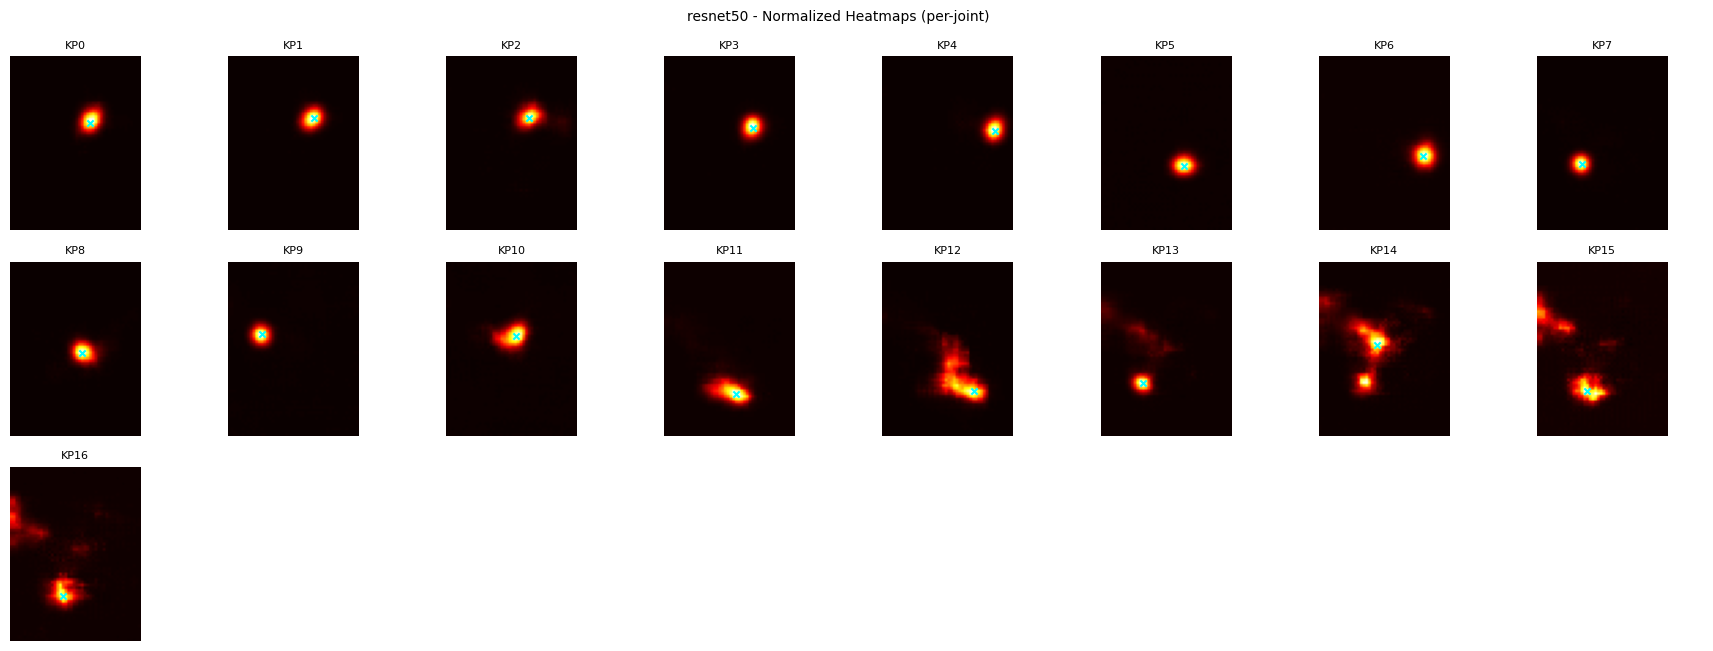


--- Model: hrnet_w32 | heatmaps shape: (17, 64, 48) | scale_factor: 1.0 ---
KP 00: score=0.618, sum=37.6, nonzero=3071, argmax=(23, 29), mapped~(29.0,23.0), kp_pred=[386.5, 143.8]
KP 01: score=0.775, sum=33.1, nonzero=3071, argmax=(23, 30), mapped~(30.0,23.0), kp_pred=[397.9, 134.6]
KP 02: score=0.388, sum=40.3, nonzero=3071, argmax=(23, 29), mapped~(29.0,23.0), kp_pred=[392.5, 127.1]
KP 03: score=0.765, sum=32.8, nonzero=3071, argmax=(26, 31), mapped~(31.0,26.0), kp_pred=[415.1, 167.3]
KP 04: score=0.704, sum=36.1, nonzero=3071, argmax=(26, 40), mapped~(40.0,26.0), kp_pred=[535.9, 178.1]
KP 05: score=0.649, sum=55.5, nonzero=3071, argmax=(40, 30), mapped~(30.0,40.0), kp_pred=[400.8, 356.4]
KP 06: score=0.634, sum=66.9, nonzero=3071, argmax=(33, 39), mapped~(39.0,33.0), kp_pred=[521.9, 277.2]
KP 07: score=0.936, sum=34.7, nonzero=3071, argmax=(39, 16), mapped~(16.0,39.0), kp_pred=[212.0, 350.5]
KP 08: score=0.542, sum=64.5, nonzero=3071, argmax=(34, 30), mapped~(30.0,34.0), kp_pred=[3

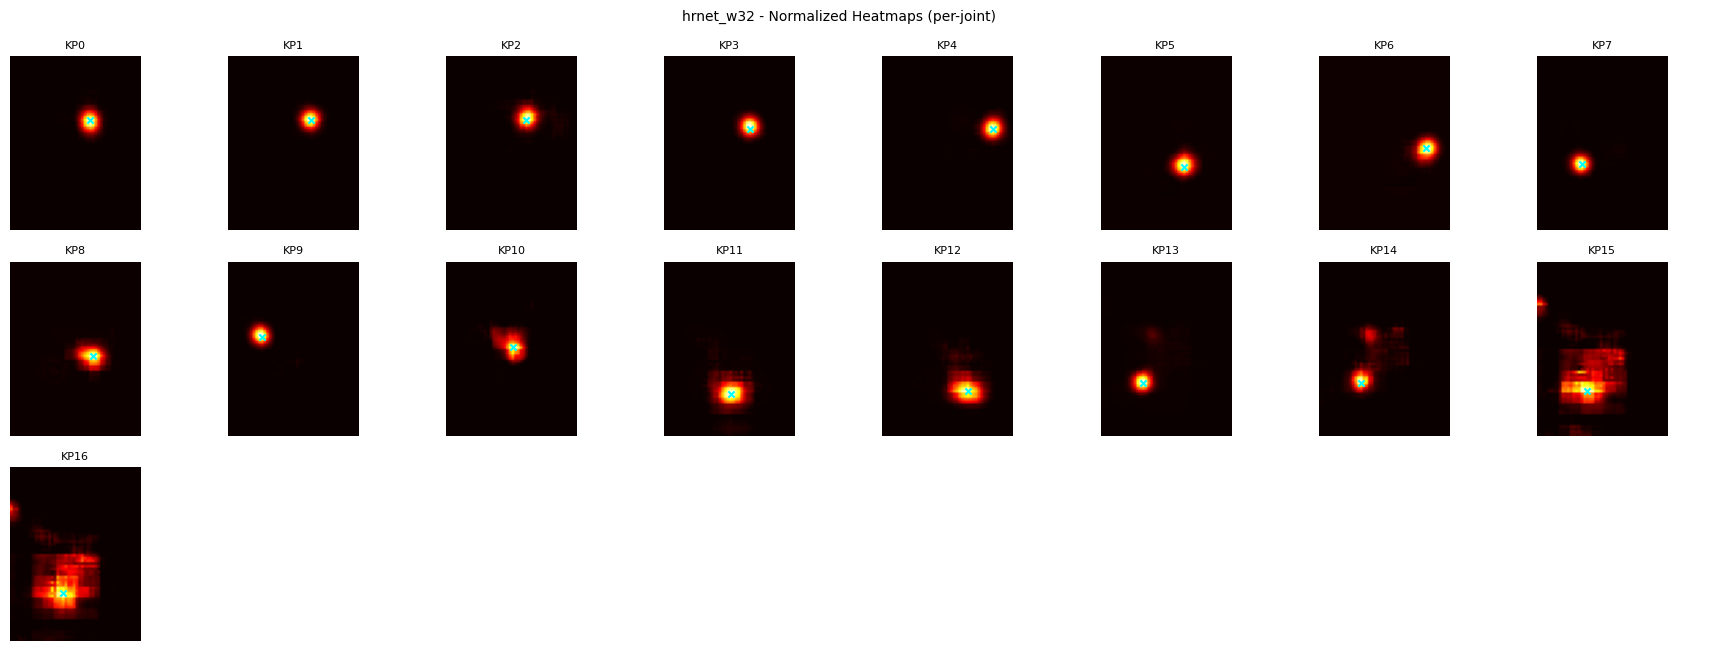


--- Model: vitpose_small | heatmaps shape: (17, 64, 48) | scale_factor: 1.0 ---
KP 00: score=0.686, sum=41.2, nonzero=3071, argmax=(22, 28), mapped~(28.0,22.0), kp_pred=[385.8, 135.4]
KP 01: score=0.744, sum=39.8, nonzero=3071, argmax=(22, 29), mapped~(29.0,22.0), kp_pred=[396.0, 126.4]
KP 02: score=0.483, sum=43.6, nonzero=3071, argmax=(22, 29), mapped~(29.0,22.0), kp_pred=[397.9, 120.0]
KP 03: score=0.778, sum=47.7, nonzero=3071, argmax=(24, 31), mapped~(31.0,24.0), kp_pred=[422.6, 162.8]
KP 04: score=0.663, sum=41.8, nonzero=3071, argmax=(26, 39), mapped~(39.0,26.0), kp_pred=[532.3, 181.0]
KP 05: score=0.667, sum=57.9, nonzero=3071, argmax=(40, 29), mapped~(29.0,40.0), kp_pred=[400.5, 359.9]
KP 06: score=0.438, sum=146.1, nonzero=3071, argmax=(34, 37), mapped~(37.0,34.0), kp_pred=[497.9, 297.7]
KP 07: score=0.961, sum=55.4, nonzero=3071, argmax=(39, 15), mapped~(15.0,39.0), kp_pred=[209.3, 352.5]
KP 08: score=0.239, sum=177.8, nonzero=3071, argmax=(34, 30), mapped~(30.0,34.0), kp_p

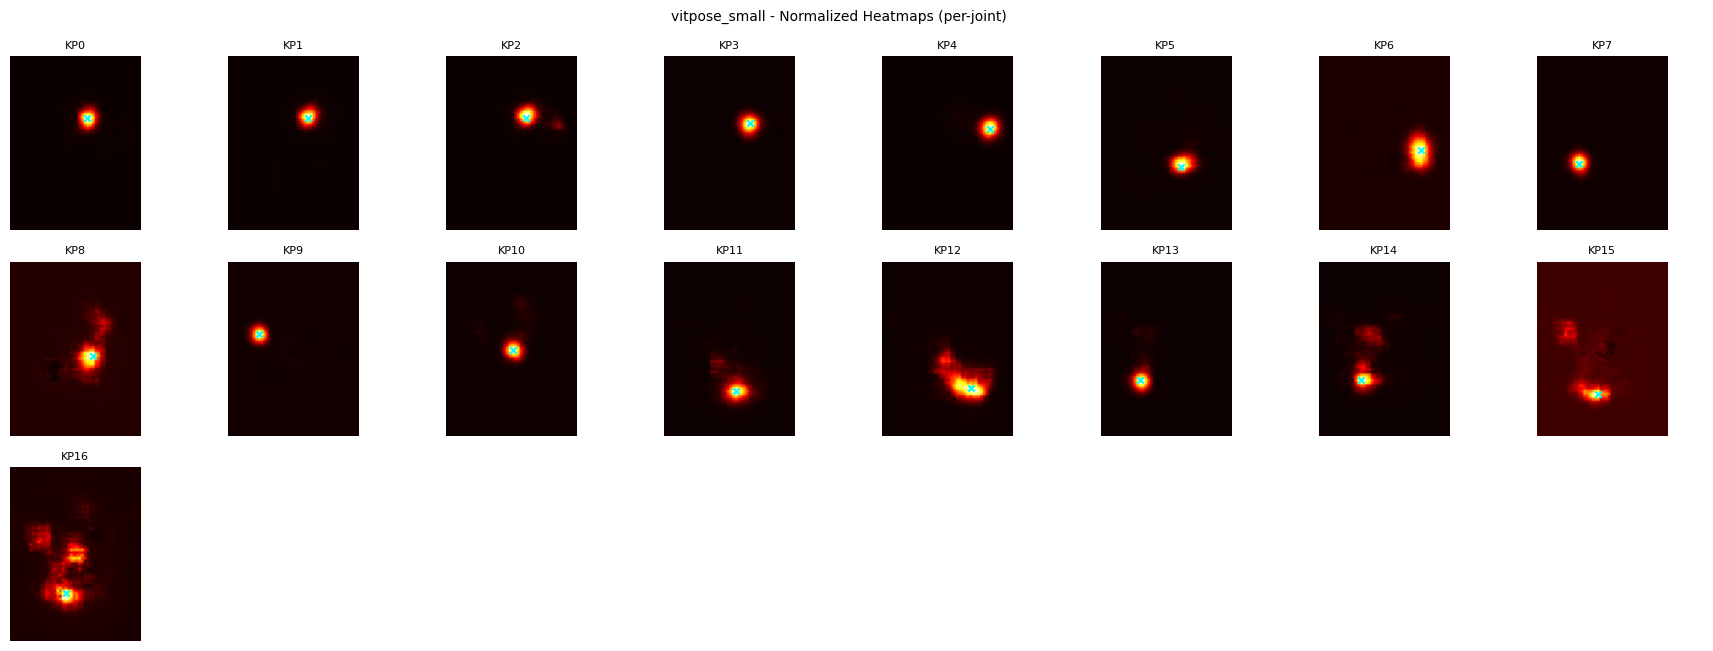

In [9]:
import math

def inspect_heatmaps(inference_results, show_normalized=True, max_per_row=8):
    for model_name, res in inference_results.items():
        hm_obj = res['heatmap']
        hm = hm_obj.data  # shape (K, H, W)
        sf = getattr(hm_obj, 'scale_factor', None)
        print(f"\n--- Model: {model_name} | heatmaps shape: {hm.shape} | scale_factor: {sf} ---")
        unique_positions = set()
        for k in range(hm.shape[0]):
            S = float(hm[k].sum())
            NZ = int(np.count_nonzero(hm[k]))
            arg = np.unravel_index(int(np.argmax(hm[k])), hm[k].shape)
            mapped_x = arg[1] / (sf if sf else 1.0)
            mapped_y = arg[0] / (sf if sf else 1.0)
            kp_xy = res['keypoints'][k] if 'keypoints' in res else None
            score = float(res['scores'][k]) if 'scores' in res else None
            unique_positions.add(arg)
            kp_str = f"[{kp_xy[0]:.1f}, {kp_xy[1]:.1f}]" if kp_xy is not None else "None"
            print(f"KP {k:02d}: score={score:.3f}, sum={S:.1f}, nonzero={NZ}, argmax={arg}, mapped~({mapped_x:.1f},{mapped_y:.1f}), kp_pred={kp_str}")
        print(f"Unique argmax positions count: {len(unique_positions)} (should be >1 if different peaks exist)")
        # Quick check: many heatmaps all-zero?
        all_zero = [k for k in range(hm.shape[0]) if hm[k].max() <= 1e-12]
        if len(all_zero) > 0:
            print(f"WARNING: {len(all_zero)}/{hm.shape[0]} heatmaps have near-zero max (indices): {all_zero[:10]}{'...' if len(all_zero)>10 else ''}")
        # Normalized visualization per keypoint to detect small peaks
        if show_normalized:
            K = hm.shape[0]
            cols = min(max_per_row, K)
            rows = math.ceil(K / cols)
            fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))
            axes = np.array(axes).reshape(rows, cols)
            for k in range(rows*cols):
                r, c = divmod(k, cols)
                ax = axes[r, c]
                if k < K:
                    arr = hm[k].astype(np.float32)
                    m = arr.max()
                    norm = arr / (m + 1e-12)
                    ax.imshow(norm, cmap='hot', vmin=0, vmax=1)
                    arg = np.unravel_index(int(np.argmax(arr)), arr.shape)
                    ax.scatter(arg[1], arg[0], c='cyan', s=20, marker='x')
                    ax.set_title(f"KP{k}", fontsize=8)
                ax.axis('off')
            plt.suptitle(f"{model_name} - Normalized Heatmaps (per-joint)", fontsize=10)
            plt.tight_layout()
            plt.show()

# Run inspection
inspect_heatmaps(inference_results)


## 8. Heatmap Extraction & Normalization Visualization

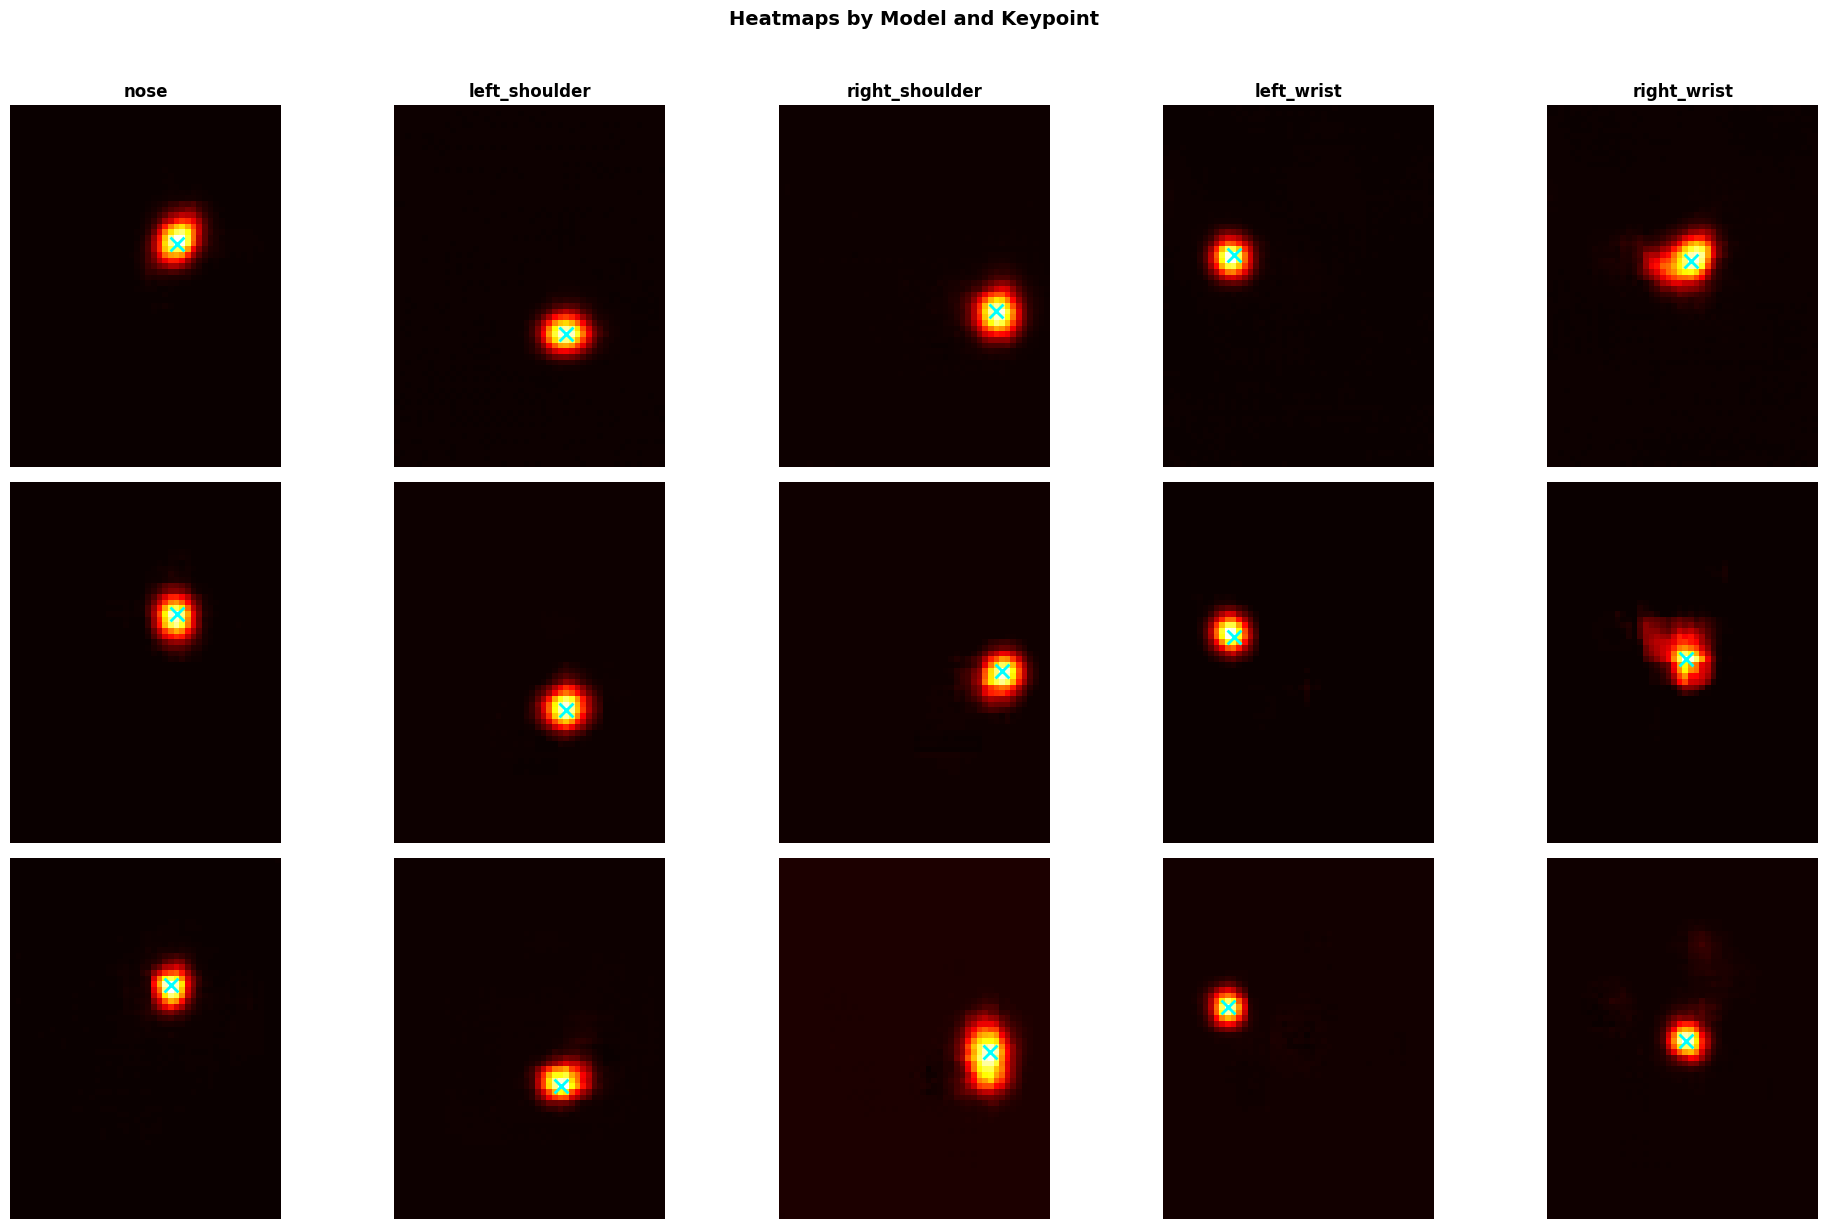

In [10]:
if 'inference_results' in dir() and len(inference_results) > 0:
    # Keypoints of interest to visualize
    keypoints_to_show = [
        (0, 'nose'),
        (5, 'left_shoulder'),
        (6, 'right_shoulder'),
        (9, 'left_wrist'),
        (10, 'right_wrist')
    ]
    
    n_models = len(inference_results)
    n_keypoints = len(keypoints_to_show)
    
    fig, axes = plt.subplots(n_models, n_keypoints, figsize=(4*n_keypoints, 4*n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    for row, (model_name, result) in enumerate(inference_results.items()):
        heatmap = result['heatmap'].data
        
        for col, (kp_idx, kp_name) in enumerate(keypoints_to_show):
            ax = axes[row, col]
            im = ax.imshow(heatmap[kp_idx], cmap='hot', vmin=0, vmax=1)
            
            # Find maximum
            max_idx = np.unravel_index(np.argmax(heatmap[kp_idx]), heatmap[kp_idx].shape)
            ax.scatter(max_idx[1], max_idx[0], c='cyan', s=100, marker='x', linewidths=2)
            
            if row == 0:
                ax.set_title(f"{kp_name}", fontsize=12, fontweight='bold')
            if col == 0:
                ax.set_ylabel(model_name, fontsize=12, fontweight='bold')
            
            ax.axis('off')
    
    plt.suptitle("Heatmaps by Model and Keypoint", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No inference results to visualize")

## 9. Keypoint Overlay on Image Space

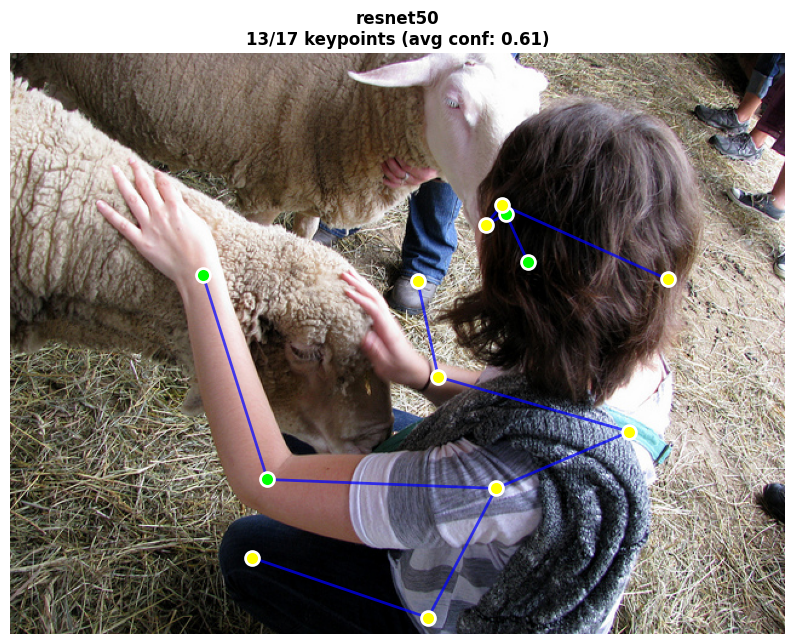

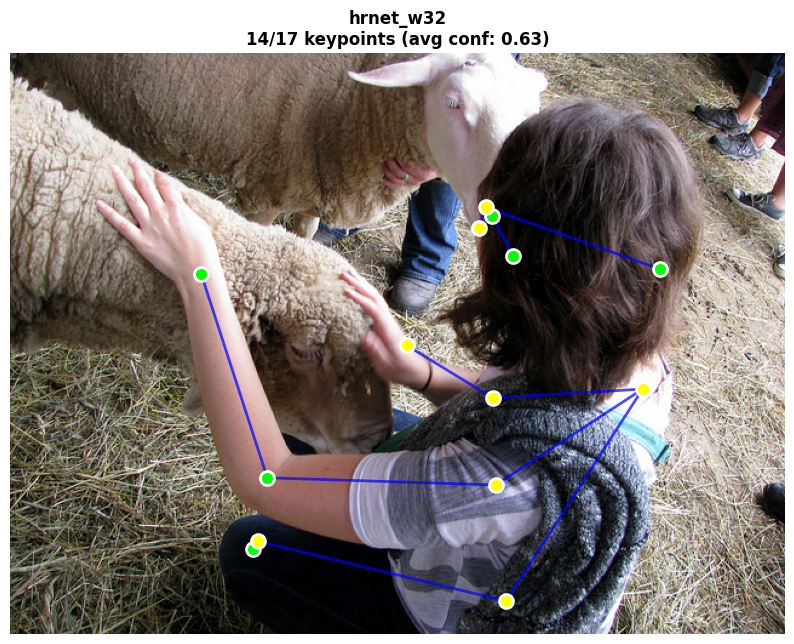

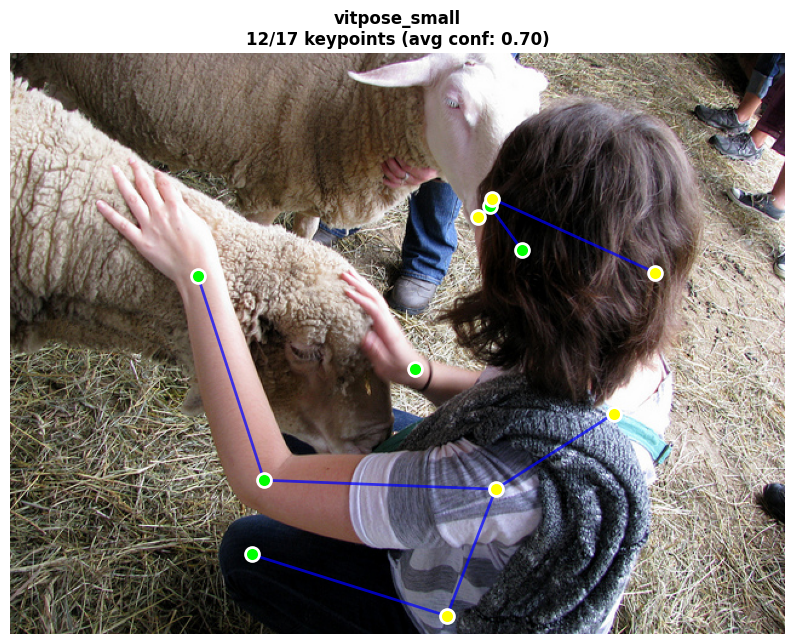

In [11]:
def visualize_pose(image, keypoints, scores, model_name, threshold=0.3):
    """Visualizes keypoints and skeleton overlaid on image."""
    
    KEYPOINT_NAMES = [
        'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
        'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
        'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
        'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
    ]
    
    SKELETON = [
        (0, 1), (0, 2), (1, 3), (2, 4),  # Face
        (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),  # Arms
        (5, 11), (6, 12), (11, 12),  # Torso
        (11, 13), (13, 15), (12, 14), (14, 16)  # Legs
    ]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image)
    
    # Draw skeleton
    for start_idx, end_idx in SKELETON:
        if scores[start_idx] > threshold and scores[end_idx] > threshold:
            ax.plot(
                [keypoints[start_idx, 0], keypoints[end_idx, 0]],
                [keypoints[start_idx, 1], keypoints[end_idx, 1]],
                'b-', linewidth=2, alpha=0.7
            )
    
    # Draw keypoints
    for i, (x, y) in enumerate(keypoints):
        if scores[i] > threshold:
            color = 'lime' if scores[i] > 0.7 else 'yellow'
            ax.scatter(x, y, c=color, s=100, edgecolors='white', linewidths=2, zorder=5)
    
    num_detected = np.sum(scores > threshold)
    avg_score = np.mean(scores[scores > threshold]) if num_detected > 0 else 0
    ax.set_title(f"{model_name}\n{num_detected}/17 keypoints (avg conf: {avg_score:.2f})", 
                fontsize=12, fontweight='bold')
    ax.axis('off')
    
    return fig, ax


# Visualize results for each model
if 'inference_results' in dir() and len(inference_results) > 0:
    for model_name, result in inference_results.items():
        fig, ax = visualize_pose(
            test_image,
            result['keypoints'],
            result['scores'],
            model_name
        )
        plt.show()
else:
    print("⚠️ No results to visualize")

## 10. Test: StandardizedHeatmap Contract Verification

In [12]:
from pose_uncertainty.utils.types import StandardizedHeatmap

print("=== StandardizedHeatmap Verification ===")

if 'inference_results' in dir() and len(inference_results) > 0:
    for model_name, result in inference_results.items():
        hm = result['heatmap']
        
        print(f"\n📦 {model_name}:")
        print(f"   ✅ Is StandardizedHeatmap: {isinstance(hm, StandardizedHeatmap)}")
        print(f"   ✅ Data shape: {hm.data.shape}")
        print(f"   ✅ Data dtype: {hm.data.dtype}")
        print(f"   ✅ Original size: {hm.original_size}")
        print(f"   ✅ Scale factor: {hm.scale_factor}")
        print(f"   ✅ Offset: {hm.offset}")
        
        # Verify invariants
        assert hm.data.ndim == 3, "Heatmap must be 3D"
        assert hm.data.min() >= 0, "Values must be >= 0"
        assert hm.data.max() <= 1, "Values must be <= 1"
        print(f"   ✅ Invariants verified")
else:
    print("⚠️ No results to verify")

=== StandardizedHeatmap Verification ===

📦 resnet50:
   ✅ Is StandardizedHeatmap: True
   ✅ Data shape: (17, 64, 48)
   ✅ Data dtype: float32
   ✅ Original size: (480, 640)
   ✅ Scale factor: 1.0
   ✅ Offset: (0.0, 0.0)
   ✅ Invariants verified

📦 hrnet_w32:
   ✅ Is StandardizedHeatmap: True
   ✅ Data shape: (17, 64, 48)
   ✅ Data dtype: float32
   ✅ Original size: (480, 640)
   ✅ Scale factor: 1.0
   ✅ Offset: (0.0, 0.0)
   ✅ Invariants verified

📦 vitpose_small:
   ✅ Is StandardizedHeatmap: True
   ✅ Data shape: (17, 64, 48)
   ✅ Data dtype: float32
   ✅ Original size: (480, 640)
   ✅ Scale factor: 1.0
   ✅ Offset: (0.0, 0.0)
   ✅ Invariants verified


## 11. Cross-Model Architecture Comparison


=== MODEL COMPARISON ===
Model                Keypoints    Avg. Conf          Max Conf
----------------------------------------------------------------------
resnet50             13/17        0.613              0.917
hrnet_w32            14/17        0.631              0.936
vitpose_small        12/17        0.700              1.026


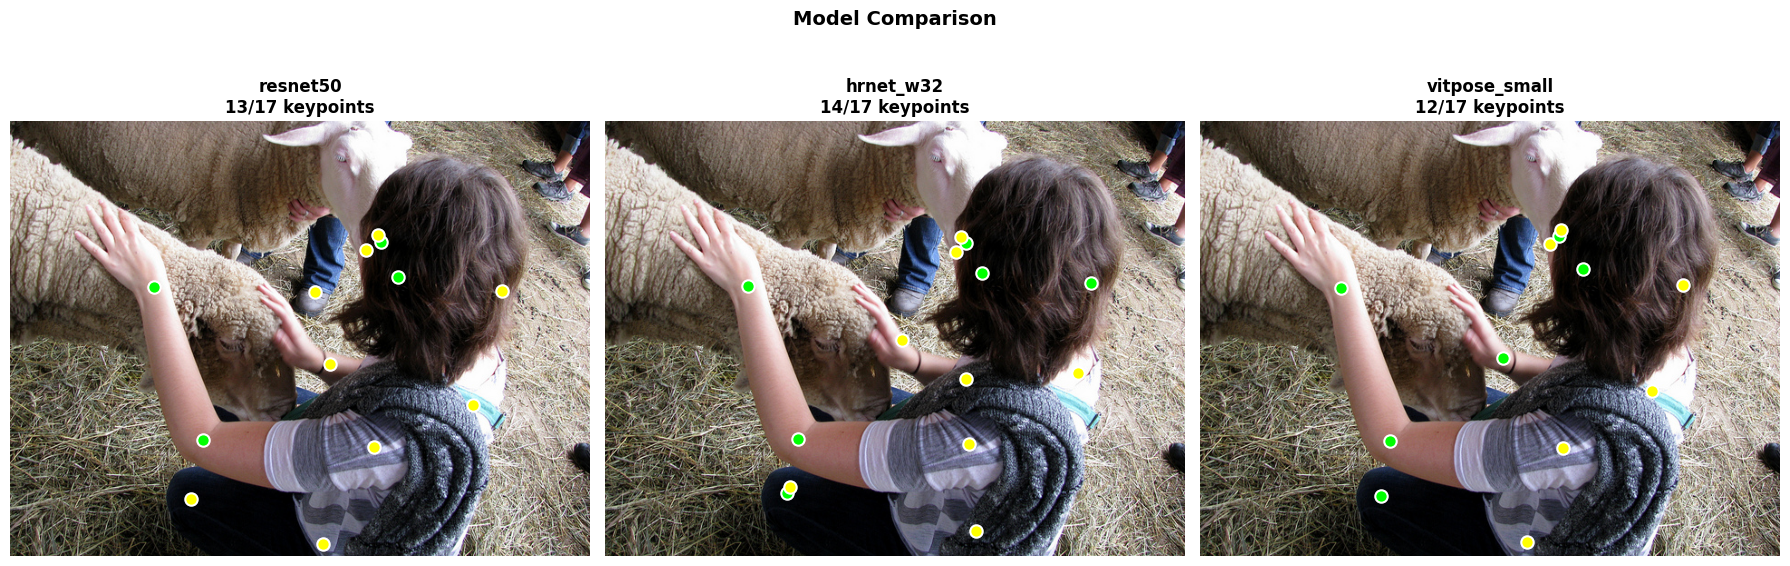

In [13]:
if 'inference_results' in dir() and len(inference_results) > 1:
    print("\n=== MODEL COMPARISON ===")
    print(f"{'Model':<20} {'Keypoints':<12} {'Avg. Conf':<18} {'Max Conf'}")
    print("-" * 70)
    
    for model_name, result in inference_results.items():
        scores = result['scores']
        num_detected = np.sum(scores > 0.3)
        avg_score = np.mean(scores[scores > 0.3]) if num_detected > 0 else 0
        max_score = np.max(scores)
        
        print(f"{model_name:<20} {num_detected:>2}/17       {avg_score:>6.3f}             {max_score:>6.3f}")
    
    # Comparative visualization
    n_models = len(inference_results)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 6))
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, result) in enumerate(inference_results.items()):
        ax = axes[idx]
        ax.imshow(test_image)
        
        keypoints = result['keypoints']
        scores = result['scores']
        
        for i, (x, y) in enumerate(keypoints):
            if scores[i] > 0.3:
                color = 'lime' if scores[i] > 0.7 else 'yellow'
                ax.scatter(x, y, c=color, s=80, edgecolors='white', linewidths=1.5)
        
        num_detected = np.sum(scores > 0.3)
        ax.set_title(f"{model_name}\n{num_detected}/17 keypoints", fontweight='bold')
        ax.axis('off')
    
    plt.suptitle("Model Comparison", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ At least 2 models required for comparison")

## 12. Summary & Adapter Architecture Conclusions

The adapter layer provides complete isolation between third-party framework implementations (MMPose) and the robust TTA uncertainty quantification pipeline.

In [14]:
print("=" * 70)
print("TEST SUMMARY")
print("=" * 70)

# Count passed tests
tests_passed = 0
total_tests = 0

# Test 1: ModelPathResolver
total_tests += 1
if 'resolver' in dir():
    tests_passed += 1
    print("✅ ModelPathResolver: OK")
else:
    print("❌ ModelPathResolver: FAILED")

# Test 2: Loaded models
total_tests += 1
if 'loaded_models' in dir() and len(loaded_models) > 0:
    tests_passed += 1
    print(f"✅ Model loading: {len(loaded_models)} models loaded")
else:
    print("❌ Model loading: FAILED")

# Test 3: Inference
total_tests += 1
if 'inference_results' in dir() and len(inference_results) > 0:
    tests_passed += 1
    print(f"✅ Inference: {len(inference_results)} successful predictions")
else:
    print("❌ Inferencia: FAILED")

# Test 4: MockPoseModel
total_tests += 1
try:
    mock = MockPoseModel(mode="unimodal")
    _ = mock.predict(np.zeros((256, 192, 3), dtype=np.uint8))
    tests_passed += 1
    print("✅ MockPoseModel: OK")
except Exception as e:
    print(f"❌ MockPoseModel: FAILED - {e}")

# Test 5: StandardizedHeatmap format
total_tests += 1
if 'inference_results' in dir() and len(inference_results) > 0:
    all_valid = True
    for name, result in inference_results.items():
        hm = result['heatmap']
        if not isinstance(hm, StandardizedHeatmap):
            all_valid = False
        if hm.data.ndim != 3:
            all_valid = False
    if all_valid:
        tests_passed += 1
        print("✅ StandardizedHeatmap format: OK")
    else:
        print("❌ StandardizedHeatmap format: FAILED")
else:
    print("❌ StandardizedHeatmap format: FAILED (no results)")

print(f"\n{'='*70}")
if tests_passed == total_tests:
    print(f"🎉 ALL TESTS PASSED! ({tests_passed}/{total_tests})")
    print("   Adapters are functioning correctly.")
else:
    print(f"⚠️ Some tests failed: {tests_passed}/{total_tests}")
    print("   Review the error messages above.")

print("\n" + "=" * 70)

TEST SUMMARY
✅ ModelPathResolver: OK
✅ Model loading: 3 models loaded
✅ Inference: 3 successful predictions
✅ MockPoseModel: OK
✅ StandardizedHeatmap format: OK

🎉 ALL TESTS PASSED! (5/5)
   Adapters are functioning correctly.

